<a href="https://colab.research.google.com/github/seonhak123/Credit-Card-Fraud-Detection/blob/main/CreditCard_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install lightgbm
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score
from sklearn.metrics import average_precision_score
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import precision_recall_curve

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AISECURITY/creditcard.csv')

# EDA

In [ ]:
df.shape

(284807, 31)

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Class
0    284315
1       492
Name: count, dtype: int64


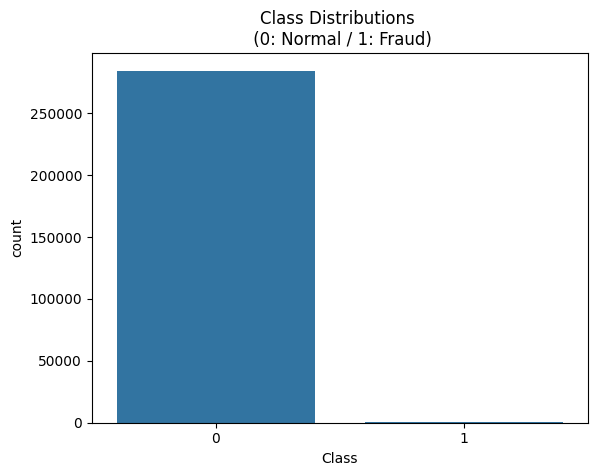

In [ ]:
#데이터 분포
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: Normal / 1: Fraud)', fontsize=12)
plt.show()

/tmp/ipykernel_3564/979910091.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(amount_val, ax=ax[0], color='r')
/tmp/ipykernel_3564/979910091.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(time_val, ax=ax[1], color='b')


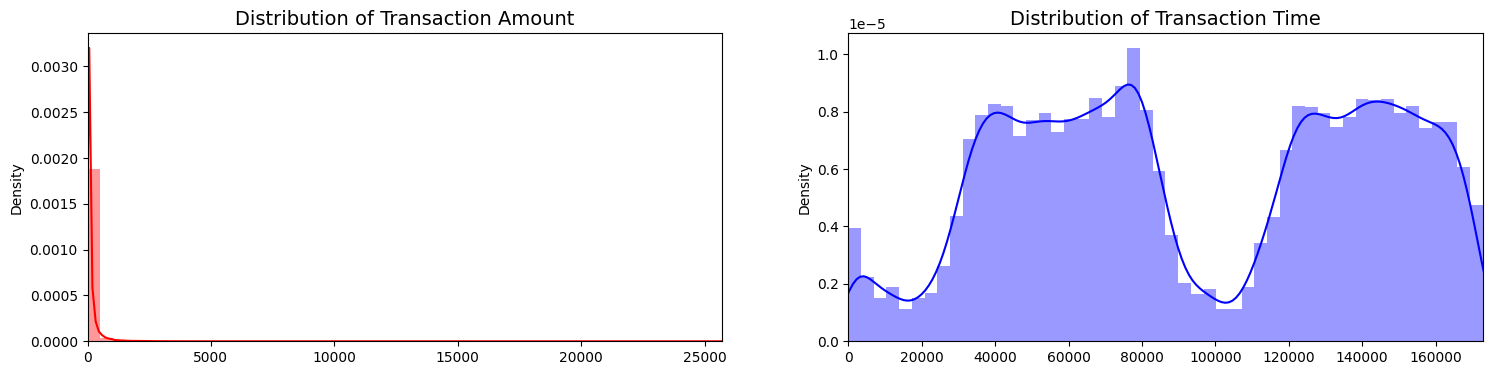

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Transaction Amount', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Distribution of Transaction Time', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

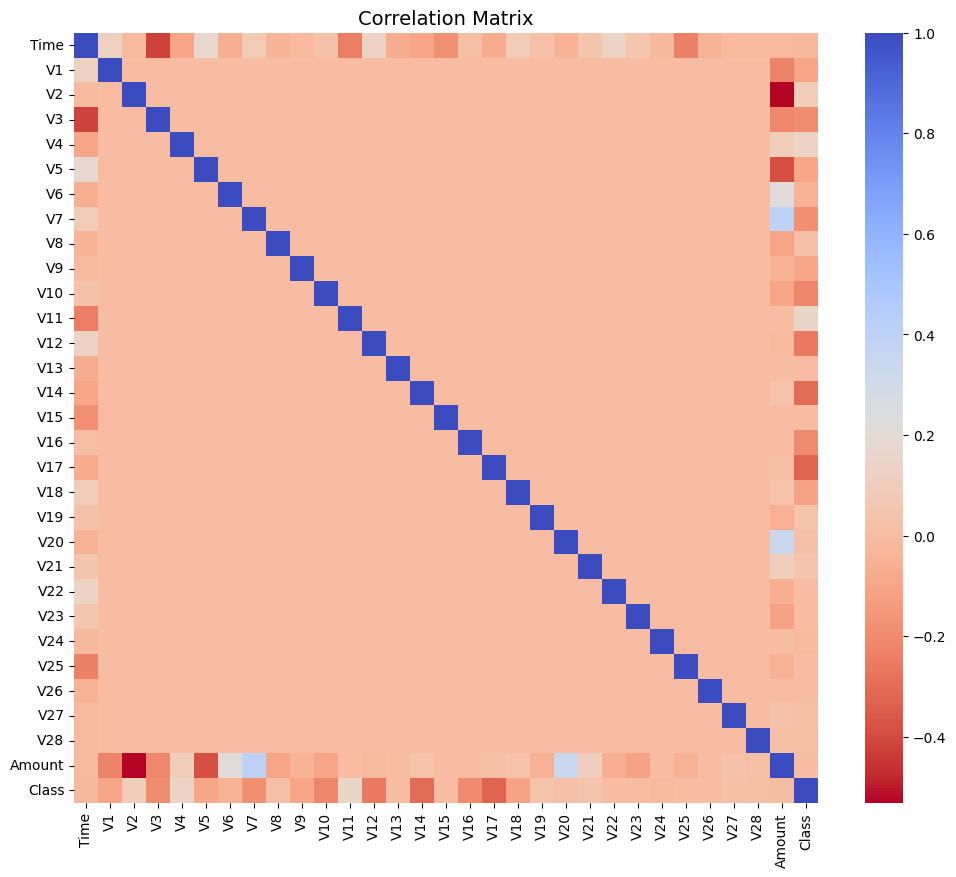

In [ ]:
#변수 간 상관관계 분석
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title("Correlation Matrix", fontsize=14)
plt.show()

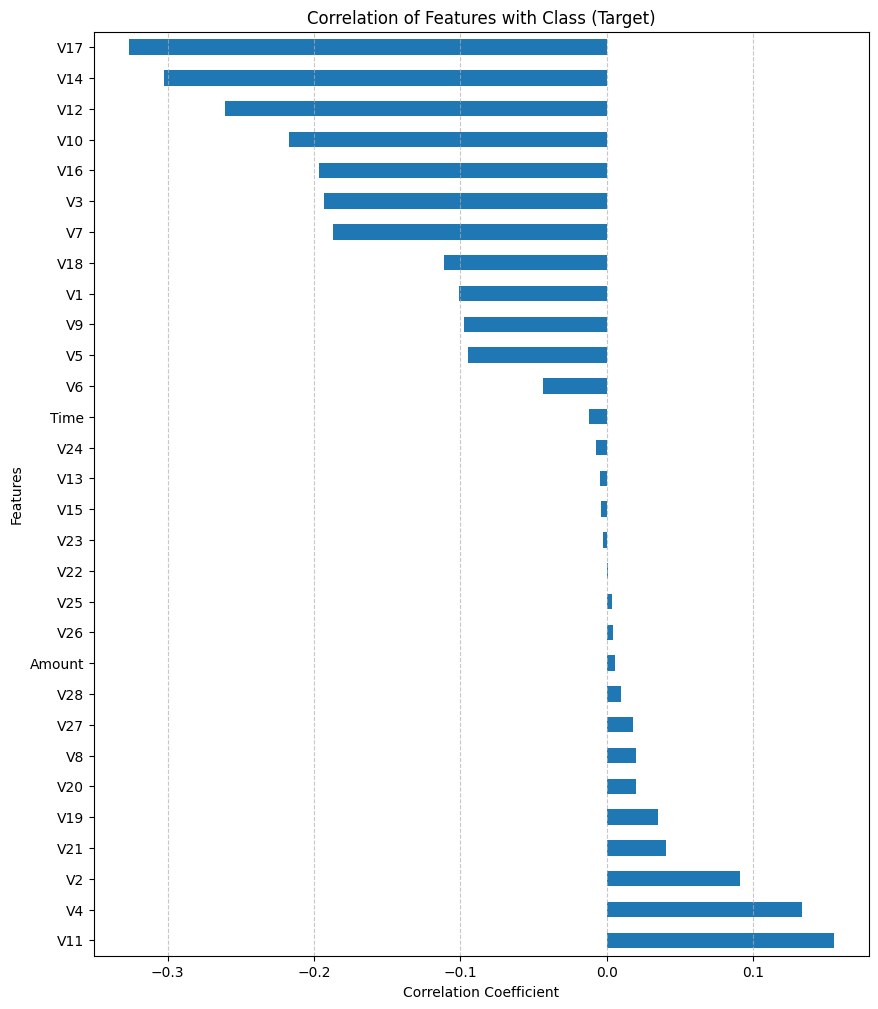

Class와 상관관계가 높은 상위 변수들:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Class와 반비례 관계가 강한 변수들:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


In [ ]:
#Class 컬럼과의 상관계수만 추출
corr_matrix = df.corr()
class_corr = corr_matrix['Class'].sort_values(ascending=False)

plt.figure(figsize=(10, 12))
class_corr.drop('Class').plot(kind='barh')

plt.title('Correlation of Features with Class (Target)', fontsize=12)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Class와 상관관계가 높은 상위 변수들:")
print(class_corr.head(10)) # 양의 상관관계
print("\nClass와 반비례 관계가 강한 변수들:")
print(class_corr.tail(10)) # 음의 상관관계

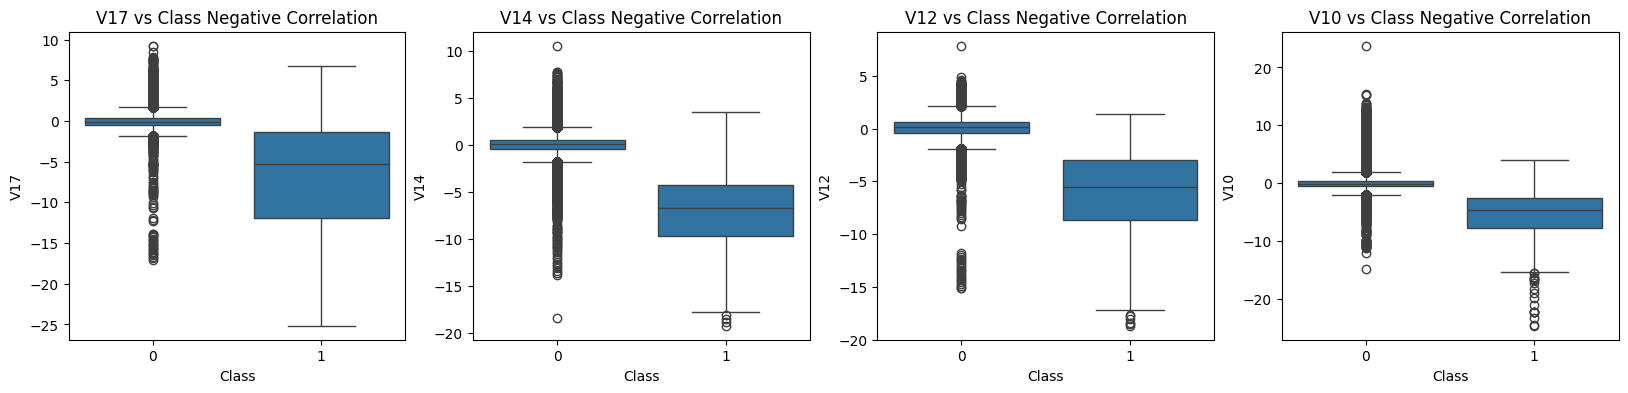

In [ ]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

sns.boxplot(x="Class", y="V17", data=df, ax=axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V14", data=df, ax=axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=df, ax=axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=df, ax=axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

In [ ]:
#Amount, Time 칼럼 스케일링
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [ ]:
#데이터 분할
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In [ ]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"SMOTE 적용 후 학습 데이터 세트 크기: {X_train_res.shape}")
print(f"SMOTE 적용 후 라벨 분포:\n{y_train_res.value_counts()}")

SMOTE 적용 후 학습 데이터 세트 크기: (398040, 30)
SMOTE 적용 후 라벨 분포:
Class
0    199020
1    199020
Name: count, dtype: int64


# 1. 단일 모델 학습 & 파라미터 조정

In [ ]:
models = {
    "Linear Classification": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}

# 2. 결과 저장을 위한 딕셔너리
results = {}

# 3. 모델 학습 및 평가
for name, model in models.items():
    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    # 평가 지표 계산
    ap_score = average_precision_score(y_test, y_score)
    results[name] = ap_score

    print(f"{name} AUPRC: {ap_score:.4f}")
    print(classification_report(y_test, y_pred))
    print("\n")

Linear Classification AUPRC: 0.7076
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85295
           1       0.06      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443



Random Forest AUPRC: 0.8274
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.78      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.89      0.91     85443
weighted avg       1.00      1.00      1.00     85443





/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:15:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUPRC: 0.8249
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.77      0.78      0.78       148

    accuracy                           1.00     85443
   macro avg       0.88      0.89      0.89     85443
weighted avg       1.00      1.00      1.00     85443



[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM AUPRC: 0.8008
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           

## 파라미터 조정

In [ ]:
import optuna

"""
아래 objective 함수와 study.optimize 과정은 초기 모델 성능 극대화를 위해 Optuna를 사용하여 총 10회의 Trial을 수행한 기록
런타임 시간을 절약하기 위해 현재는 실제 실행되지 않도록 주석 처리
"""

'''
1. Random Forest 파라미터 최적화
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42,
        'n_jobs': -1
    }
    model = RandomForestClassifier(**param)
    model.fit(X_train_res, y_train_res)
    y_score = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_score)

2. XGBoost 파라미터 최적화
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 30),
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = XGBClassifier(**param)
    model.fit(X_train_res, y_train_res)
    y_score = model.predict_proba(X_test)[:, 1]
    return average_precision_score(y_test, y_score)

# study_rf = optuna.create_study(direction='maximize')
# study_rf.optimize(objective_rf, n_trials=10)
# study_xgb = optuna.create_study(direction='maximize')
# study_xgb.optimize(objective_xgb, n_trials=20)
'''

rf_best_params = {
    'n_estimators': 495,
    'max_depth': 9,
    'min_samples_split': 5,
    'min_samples_leaf': 6,
    'criterion': 'entropy',
    'n_jobs': -1,
    'random_state': 42
}

xgb_best_params = {
    'n_estimators': 455,
    'max_depth': 9,
    'learning_rate': 0.08903150630423762,
    'subsample': 0.7754599867108974,
    'colsample_bytree': 0.5996549945015783,
    'scale_pos_weight': 3.4735511118988494,
    'random_state': 42,
    'eval_metric': 'logloss'
}

### RandomForest 최종 모델 성능

In [ ]:
final_rf_model = RandomForestClassifier(**rf_best_params)

final_rf_model.fit(X_train_res, y_train_res)

y_score_rf = final_rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = final_rf_model.predict(X_test)


print(f"Final AUPRC: {average_precision_score(y_test, y_score_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

Final AUPRC: 0.8140
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.40      0.84      0.55       148

    accuracy                           1.00     85443
   macro avg       0.70      0.92      0.77     85443
weighted avg       1.00      1.00      1.00     85443



### XGBoost 최종 모델 성능

In [ ]:
final_xgb_model = XGBClassifier(**xgb_best_params)

final_xgb_model.fit(X_train_res, y_train_res)

y_score = final_xgb_model.predict_proba(X_test)[:, 1]
y_pred = final_xgb_model.predict(X_test)


print(f"Final AUPRC: {average_precision_score(y_test, y_score):.4f}")
print(classification_report(y_test, y_pred))

Final AUPRC: 0.8341
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.82      0.82      0.82       148

    accuracy                           1.00     85443
   macro avg       0.91      0.91      0.91     85443
weighted avg       1.00      1.00      1.00     85443



#2. Voting & Stacking

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
final_best_rf = RandomForestClassifier(**rf_best_params)
final_best_xgb = XGBClassifier(**xgb_best_params)

#Voting
voting_model = VotingClassifier(
    estimators=[('rf', final_best_rf), ('xgb', final_best_xgb)],
    voting='soft',
    weights=[0.3, 0.7]
)

voting_model.fit(X_train_res, y_train_res)
y_voting_score = voting_model.predict_proba(X_test)[:, 1]

v_auprc = average_precision_score(y_test, y_voting_score)
print(f"보팅 결과 AUPRC: {v_auprc:.4f}")


#Stacking
stack_model = StackingClassifier(
    estimators=[('rf', final_best_rf), ('xgb', final_best_xgb)],
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train_res, y_train_res)
y_stack_score = stack_model.predict_proba(X_test)[:, 1]

s_auprc = average_precision_score(y_test, y_stack_score)
print(f"스태킹 결과 AUPRC: {s_auprc:.4f}")

보팅 결과 AUPRC: 0.8339
스태킹 결과 AUPRC: 0.8339


#3. Feature Selection

In [ ]:
# 절대값 기준 정렬 후 가장 상관관계가 낮은 하위 5개 추출
bottom_5_features = abs(class_corr).sort_values(ascending=True).head(5).index.tolist()

print(f"하위 5개 제거 대상: {bottom_5_features}")

하위 5개 제거 대상: ['V22', 'V23', 'V25', 'V15', 'V26']


In [ ]:
X_selected = X.drop(columns=bottom_5_features)

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.3, random_state=42, stratify=y)

sm = SMOTE(random_state=42)
X_train_res_sel, y_train_res_sel = sm.fit_resample(X_train_sel, y_train_sel)


final_xgb_sel = XGBClassifier(**xgb_best_params)
final_xgb_sel.fit(X_train_res_sel, y_train_res_sel)


y_score_sel = final_xgb_sel.predict_proba(X_test_sel)[:, 1]
new_auprc = average_precision_score(y_test_sel, y_score_sel)


print(f"하위 5개 변수 제거 후 AUPRC: {new_auprc:.4f}")

하위 5개 변수 제거 후 AUPRC: 0.8411


In [ ]:
print("======= [최종 성능 비교] =======")
print(f"1. 단일 XGBoost (Base):      0.8341")
print(f"2. Soft Voting Ensemble:     {v_auprc:.4f}")
print(f"3. Stacking Ensemble:       {s_auprc:.4f}")
print(f"4. Feature Selection_XGB:    {new_auprc:.4f}")
print("======================================")

======= [최종 성능 비교] =======
1. 단일 XGBoost (Base):      0.8341
2. Soft Voting Ensemble:     0.8339
3. Stacking Ensemble:       0.8339
4. Feature Selection_XGB:    0.8411
